## 1. NPS da E-commerce BR


E-commerce BR cresceu e passou a lidar com um volume cada vez maior de pedidos, entregas e interações com os clientes. Com isso, a área de experiência do cliente solicitou apoio do time de Ciência de Dados da BR para, em colaboração, encontrar possíveis hipóteses de como melhorar a satisfação dos consumidores de maneira proativa através do entendimento de quais fatores operacionais influenciam nas respostas obtidas até o momento.

A área de Experiência do Cliente percebeu que, mesmo com indicadores operacionais aparentemente semelhantes, alguns clientes se tornam promotores da marca, enquanto outros se tornam detratores.

Esse EDA tem como premissas:
- Os consumidores possuem perfis variados de consumo.
- O NPS é coletado após o encerramento da jornada de compra.
- Existe variabilidade nas respostas do NPS.

E o trabalho que será detalhado abaixo busca aprofundar as interpretações obtidas pelo time de Experiência do Cliente e direcionar possíveis estratégias de negócio para melhorar a satisfação dos consumidores.

# 1.1 Cenário de negócio



O e-commerce brasileiro segue em expansão com previsão de faturar R$ 284 bilhões em 2027, crescimento de cerca de 20% comparado com o desempenho real do ano de 2025, conforme detalhado na imagem a seguir.

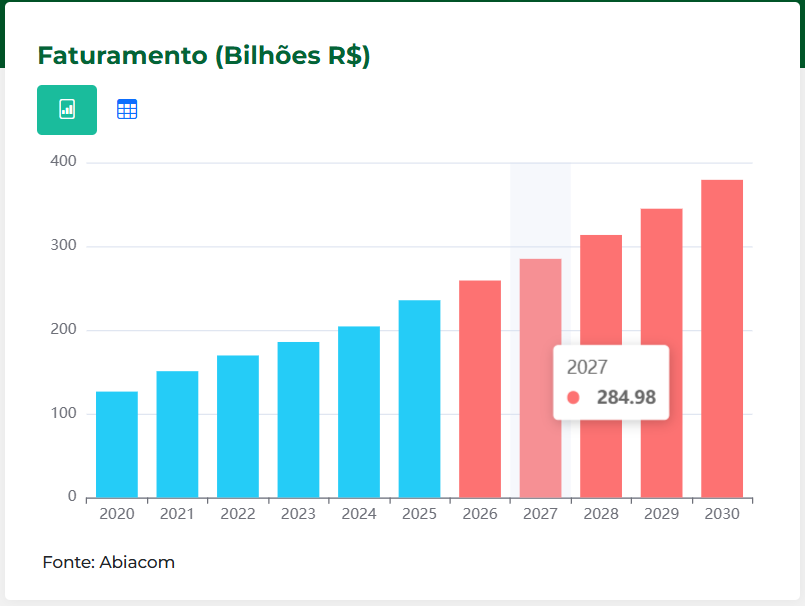

*Imagem 1 - Fonte: Abiacom - Associação Brasileira de Inteligência Artificial e E-commerce - (2026): https://dados.abcomm.org/previsao-de-vendas-online *

Os grandes players do mercado brasileiro são: Mercado Livre, Shopee, Amazon Brasil, Magazine Luiza e Americanas. Considerando que existe um aumento de faturamento de 20% projetado, nós da E-commerce BR temos a intenção de melhorar nossos indíces de satisfação para reter e atrair novos consumidores e aumentar nosso market share a fim de nos tornarmos players competivos até 2027 em um mercado extremamente competitivo e desafiador.

 Nosso principal problema de negócio hoje é manter os clientes que já são fiéis em nossa carteira, aumentar o seu faturamento conosco e expandir nossa carteira e portfólio através do marketing boca a boca, de fluxo orgânico, que têm sido muito eficiente para nós nos últimos anos.  Concluímos que a satisfação e a lealdade dos nossos consumidores são fundamentais para manter receita e aumentar nosso market share.

 Para que esse objetivo seja possível iniciamos um trabalho de 2025 de coletar a satisfação de nossos consumidores através da ferramenta NPS (Net Promoter Score).

 Dados de Janeiro de 2025 até Abril de 2025* (fictício):
  * Dados do pedido (valor, quantidade de itens, forma de pagamento);
  * Dados logísticos (tempo de entrega, atraso, tentativas);
  * Dados de atendimento (contatos, tempo de resolução);
  * Indicadores internos de negócio.

 Essa ferramenta têm sido a mais indicada porque, através dela, podemos identificar o percentual de clientes que são detratores da marca (que aumentam riscos de churn) e quais clientes são promotores da E-commerce BR (que aumentam indicadores de receita através de novos leads).

 Com a análise exploratória que será realizada neste material, teremos insumos para que as equipes de logística, atendimento, pricing, produto possam se debruçar na experimentação e exploração de hipóteses que podem aumentar nossos índices de satisfação e, consequentemente, incremento de receita.

OBS.: *As datas fictícias foram citadas para sustentar o storytelling partindo do princípio que durante a etapa de Business Understanding do CRISP-DM foi descartada a possibilidade dos dados não serem representativos.*

# 1.2. Target


Para que no futuro sejam feitos modelos preditivos de regressão e classificação que visam contribuir positivamenr no NPS que será aplicado com os consumidores  vamos primeiramente fazer uma análise exploratória (EDA) no dataset da pesquisa de forma a responder a seguinte pergunta norteadora: **"Quais são os principais fatores que contribuem para a variabilidade de satisfações no NPS da E-commerce BR?​"**

Descobrindo quais são os padrões, teremos mais condições de estruturar estratégias com os times de logística, produtos, atendimento, pricing, etc para aumentar a satisfação dos consumidores.

# 1.3. Análise Exploratória dos Dados

Quais são as bibliotecas necessárias para exploração dos dados da pesquisa?

In [2]:
#Libs
import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#Avisos
import warnings
warnings.filterwarnings('ignore')

Quais são as colunas disponíveis no dataset?

In [4]:
nps = pd.read_csv('desafio_nps_fase_1.csv')
nps.head(5)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Qual o tamanho do dataset?

In [5]:
print(f'Tamanho do dataset da pesquisa NPS (Linhas, Colunas): {nps.shape}')

Tamanho do dataset da pesquisa NPS (Linhas, Colunas): (2500, 19)


**Dicionário de Dados**
* customer_id: Identificador único do cliente.
* order_id: Identificador único do pedido.
* customer_age: Idade do cliente.
* customer_region: Região geográfica do cliente.
* customer_tenure_months: Tempo de relacionamento do cliente com a
empresa (em meses).
* order_value: Valor total do pedido.
* items_quantity: Quantidade de itens no pedido.
* discount_value: Valor de desconto aplicado ao pedido.
* payment_installments: Número de parcelas do pagamento.
* delivery_time_days: Tempo total de entrega (em dias).
* delivery_delay_days: Quantidade de dias de atraso na entrega.
* freight_value: Valor do frete.
* delivery_attempts: Número de tentativas de entrega.
* customer_service_contacts: Número de contatos do cliente com o atendimento.
* resolution_time_days: Tempo para resolução de problemas (em dias).
* complaints_count: Número de reclamações registradas pelo cliente.
* repeat_purchase_30d: Indica se houve recompra em até 30 dias após o pedido (0 = não, 1 = sim).
* csat_internal_score: Score interno de satisfação do cliente.
* nps_score: Nota de satisfação do cliente (NPS), variando de 0 a 10, coletada
após a experiência de compra.

Temos valores nulos no dataframe?

In [6]:
print(f'Quantidade de dados nulos: {nps.isnull().sum().sum()}')

Quantidade de dados nulos: 0


Quais são os nomes das colunas do dataset

In [7]:
nps.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

Criar coluna pra relacionar score de grau de satisfação entre detrator, neutro e promotor.

In [8]:
def nps_classificacao(ds):
    if ds['nps_score']<=6:
        return 'Detrator'
    elif ds['nps_score'] >=9:
        return 'Promotor'
    else:
        return 'Neutro'

In [9]:
nps['nps_classificacao'] = nps.apply(nps_classificacao, axis=1)
coluna = nps.pop('nps_classificacao')
nps.insert(16, 'nps_classificacao', coluna)
nps.head(3)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,nps_classificacao,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,Neutro,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,Detrator,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,Detrator,0,7,1.5


Quais são so tipos de dados?

In [10]:
nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

Quais são os valores únicos?

In [11]:
nps.nunique()

,0
customer_id,2500
customer_age,52
customer_region,5
customer_tenure_months,119
order_id,2500
order_value,2457
items_quantity,6
discount_value,2050
payment_installments,11
delivery_time_days,13


Estatística descritiva

In [12]:
# dataset que contenha somente infos de customer, pedido e delivery
ds_nps_1 = nps[['customer_id', 'customer_age', 'customer_region', 'order_id', 'order_value', 'delivery_time_days', 'delivery_delay_days','nps_score']]

# dataset que contenha somente infos de customer, pedido, delivery e reclamações
ds_nps_2 = nps[['customer_id', 'order_id', 'order_value', 'delivery_time_days', 'delivery_delay_days', 'freight_value','delivery_attempts','customer_service_contacts','resolution_time_days','nps_score', 'complaints_count']]

# dataset que contenha somente infos de customer, delivery, repetição de compra e reclamações
ds_nps_3 = nps[['customer_id', 'order_id', 'delivery_time_days', 'delivery_delay_days','nps_score','complaints_count','customer_service_contacts','repeat_purchase_30d']]

# dataset que contenha somente infos de reclamações, score e csat interno para estatística
ds_nps_4 = nps[['customer_age', 'order_value', 'nps_score','csat_internal_score','complaints_count','customer_service_contacts','customer_tenure_months','repeat_purchase_30d','nps_classificacao','delivery_delay_days']]

In [13]:
ds_nps_4.describe().round(2)

,customer_age,order_value,nps_score,csat_internal_score,complaints_count,customer_service_contacts,customer_tenure_months,repeat_purchase_30d,delivery_delay_days
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,434.26,4.38,2.94,4.15,1.52,61.32,0.09,2.19
std,14.89,289.77,2.51,2.38,1.78,1.23,34.48,0.28,1.45
min,18.00,7.76,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,31.00,220.24,2.60,0.70,3.00,1.00,31.00,0.00,1.00
50%,43.00,375.52,4.40,2.80,4.00,1.00,62.00,0.00,2.00
75%,56.00,577.29,6.10,4.80,5.00,2.00,91.00,0.00,3.00
max,69.00,1983.81,10.00,10.00,11.00,7.00,119.00,1.00,8.00


Analisar proporção de NPS graficamente

In [14]:
ds_nps_classif = nps['nps_classificacao'].value_counts()
ds_nps_classif .head(6)

,count
nps_classificacao,
Detrator,1851
Neutro,539
Promotor,110


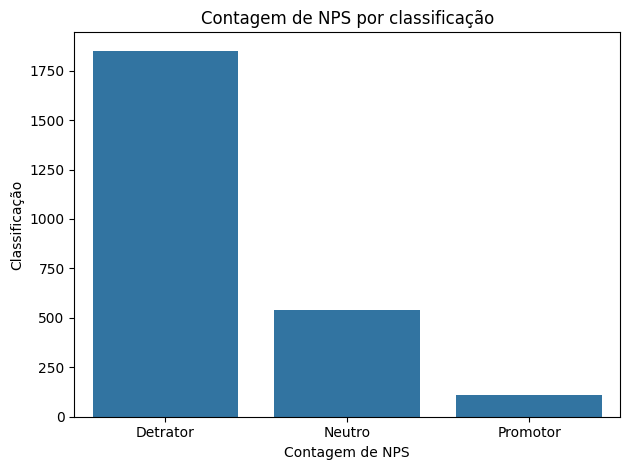

In [15]:
plt.figure()
sns.barplot(x=ds_nps_classif.index, y=ds_nps_classif.values)
plt.title("Contagem de NPS por classificação")
plt.xlabel("Contagem de NPS")
plt.ylabel("Classificação")
plt.tight_layout()
plt.show()

Pairplot

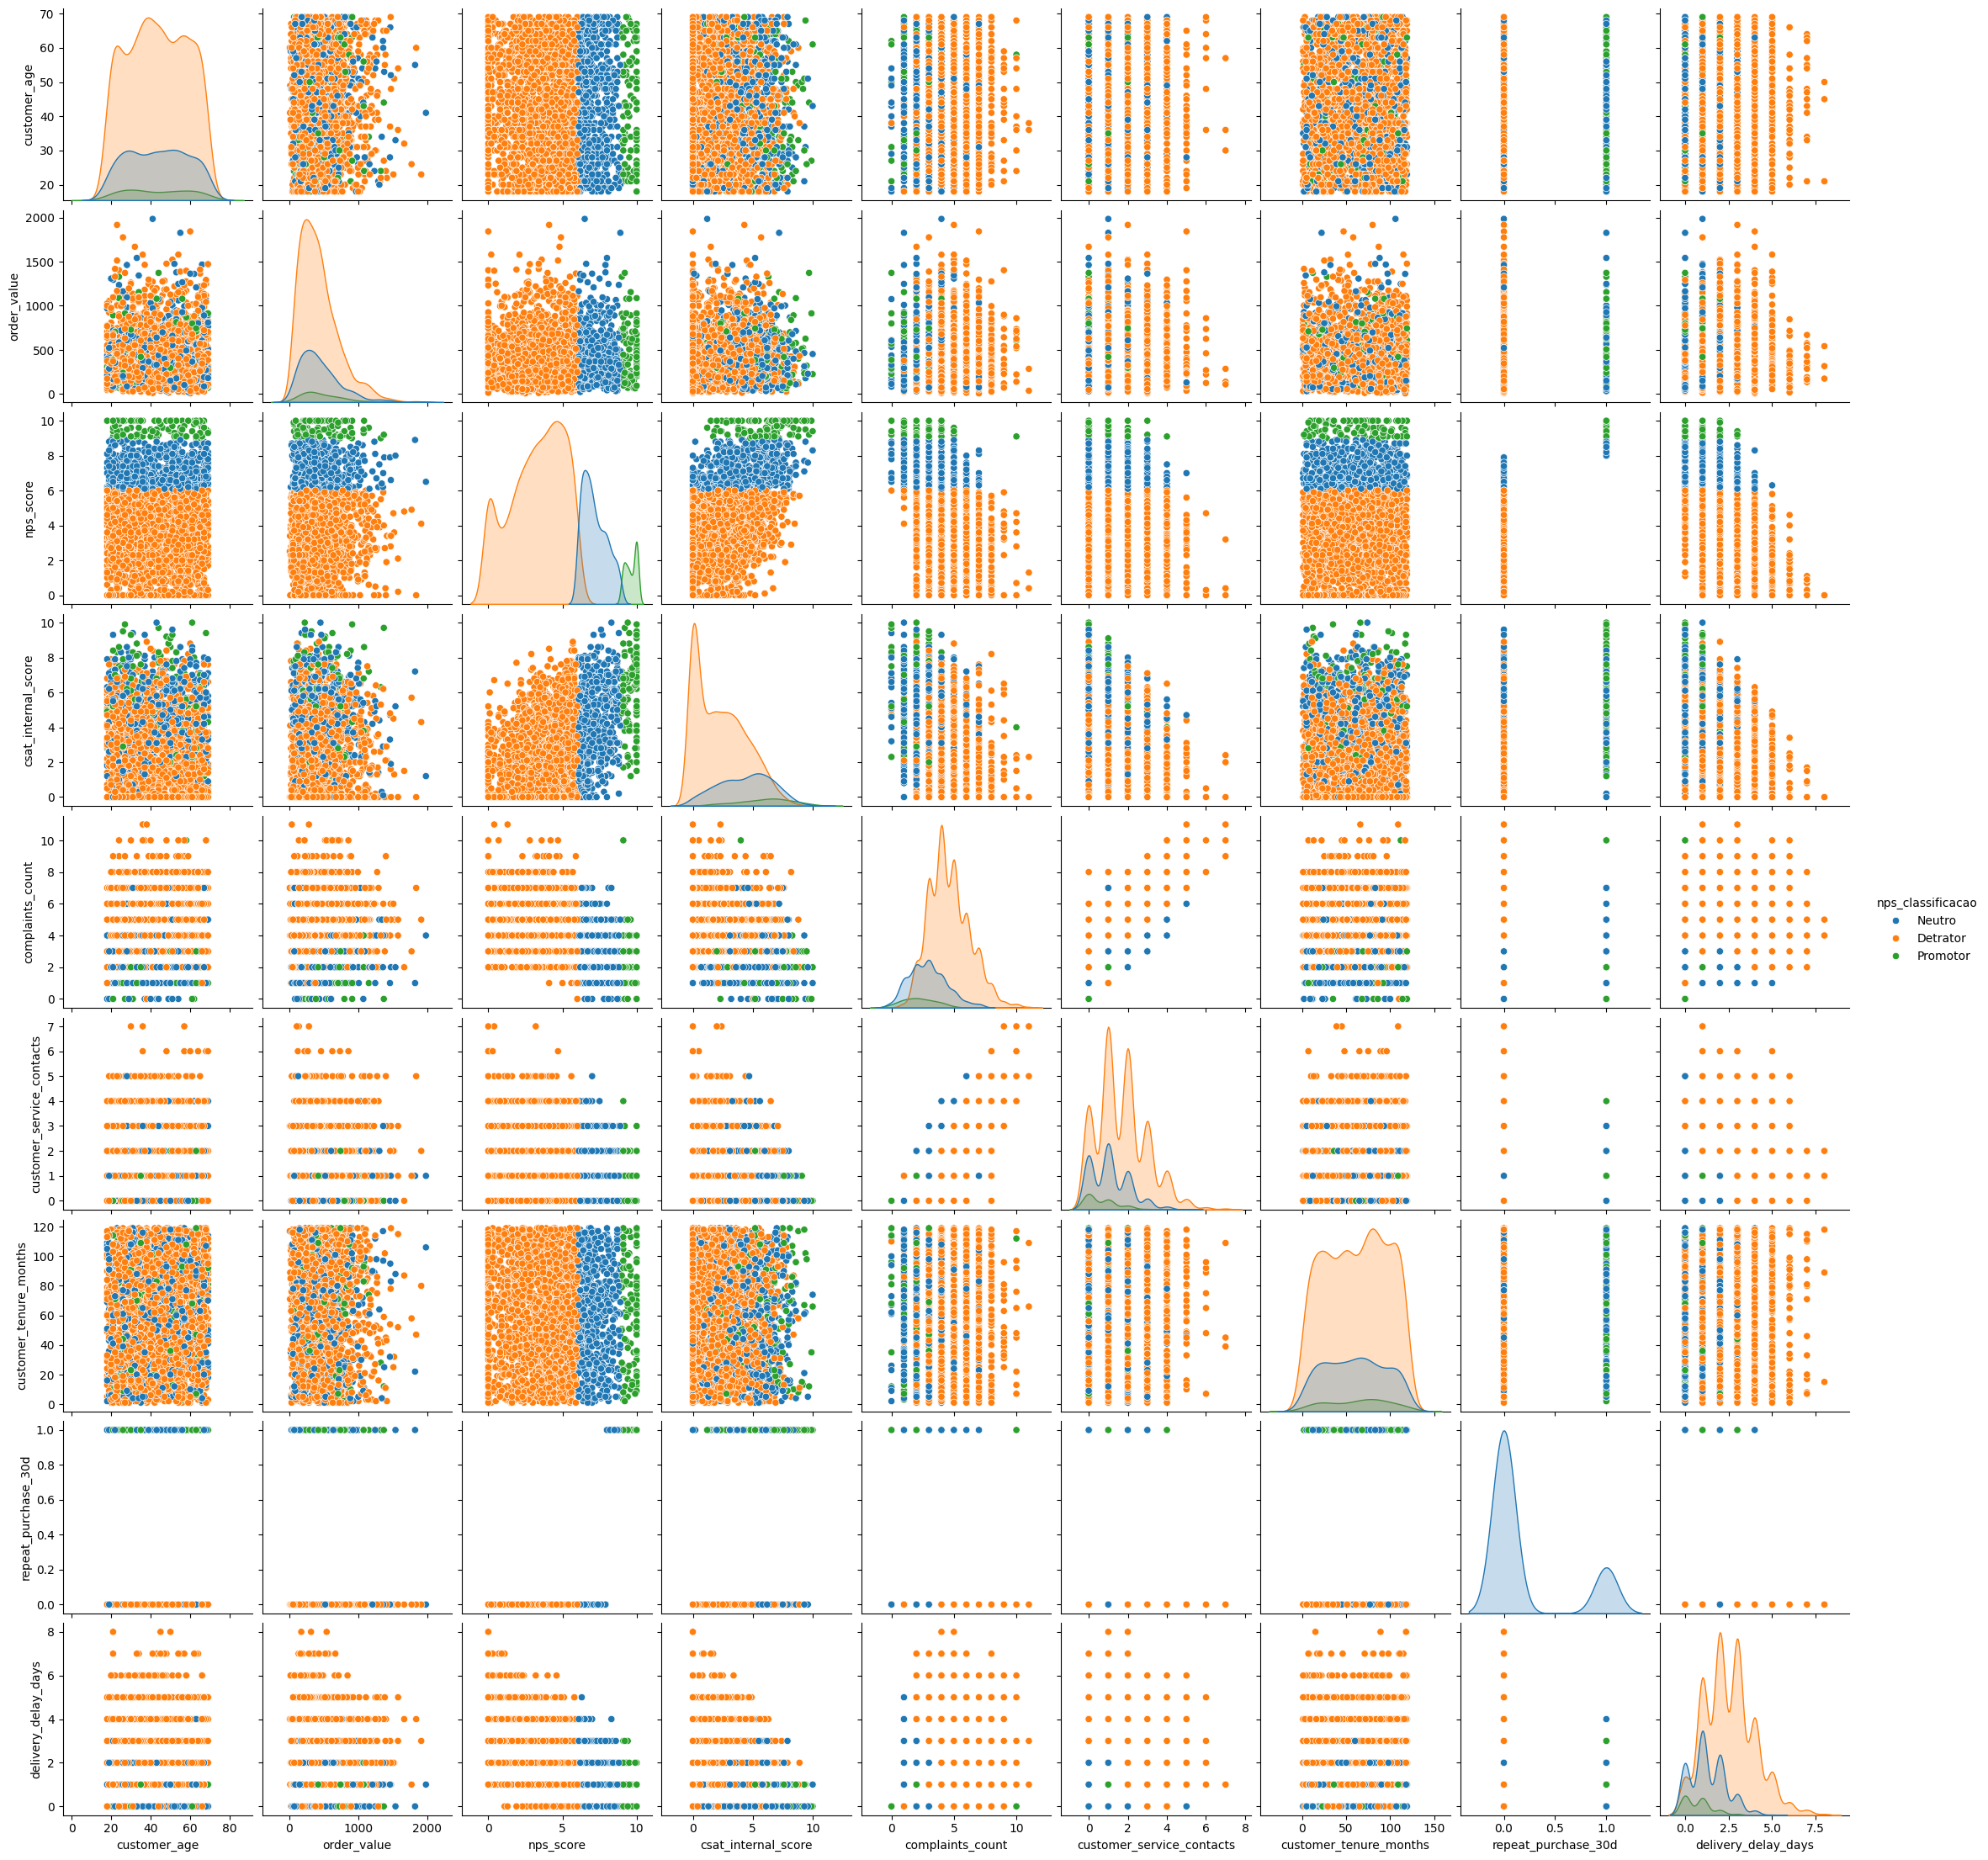

In [16]:
sns.pairplot(ds_nps_4, hue = 'nps_classificacao')

Conclusões da análise gráfica:
 * Há um certa relação linear positiva entre quantidade de reclamações e quantidade de contatos no atendimento.
 * Existem promotores com notas acima de 2 no csat_interno.
 * Não existem promotores (apenas um outlier) com mais de 5 reclamações no atendimento (relação linear negativa entre NPS e quantidade de reclamações).
 * Há uma certa relação linear negativa entre CSAT e quantidade de contatos. Quanto mais alto o CSAT, menor a quantidade de contatos no atendimento.
 * Há relação linear positiva entre nps e chance de voltar a comprar em 30 dias (quanto maios o NPS, maior a chance de comprar dentro de 30 dias).
 * Não há relação entre NPS e idade.
 * Não há correlação entre tempo de relacionamento do cliente com a empresa e o NPS.






**Análise por NPS e logística**


In [ ]:
ds_nps_5 = nps[['delivery_time_days', 'delivery_delay_days', 'nps_score','delivery_attempts','nps_classificacao']]

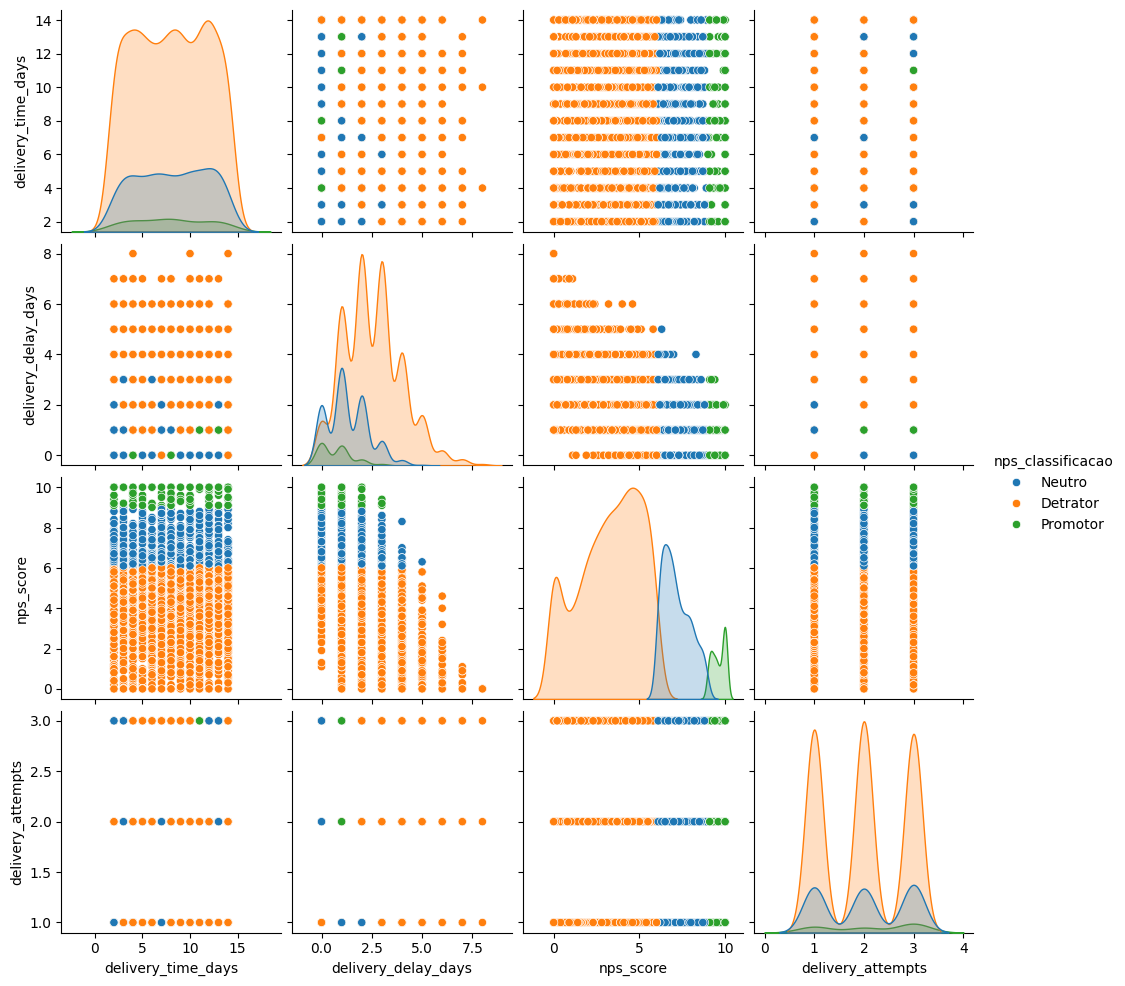

In [ ]:
sns.pairplot(ds_nps_5, hue = 'nps_classificacao')

Conclusões da análise gráfica:

* Há um certa relação linear negativa entre nps_score e dias de atraso na entrega(quanto maior o nps, menor os dias de atraso na entrega).
* Não há correlação com nps e tempo de entrega geral.




**Análise por NPS, logística e reclamações**

In [ ]:
ds_nps_6 = nps[['delivery_delay_days', 'nps_score','delivery_attempts','nps_classificacao','complaints_count']]

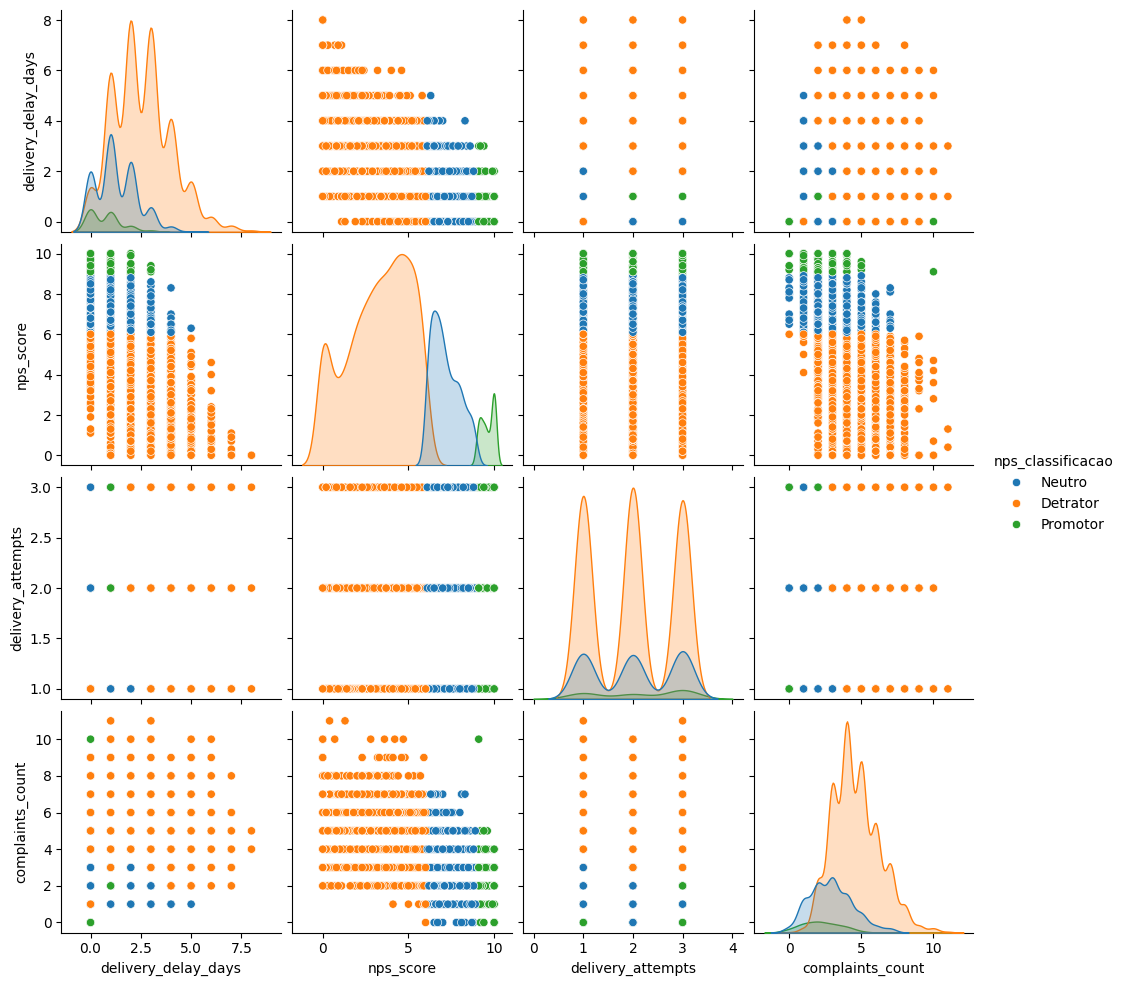

In [ ]:
sns.pairplot(ds_nps_6, hue = 'nps_classificacao')

Conclusões da análise gráfica:

*   Não há correlação entre reclamações e tempo de atraso de entrega.




**Análise por NPS e atendimento**


In [ ]:
ds_nps_7 = nps[['nps_score','resolution_time_days','nps_classificacao','complaints_count']]

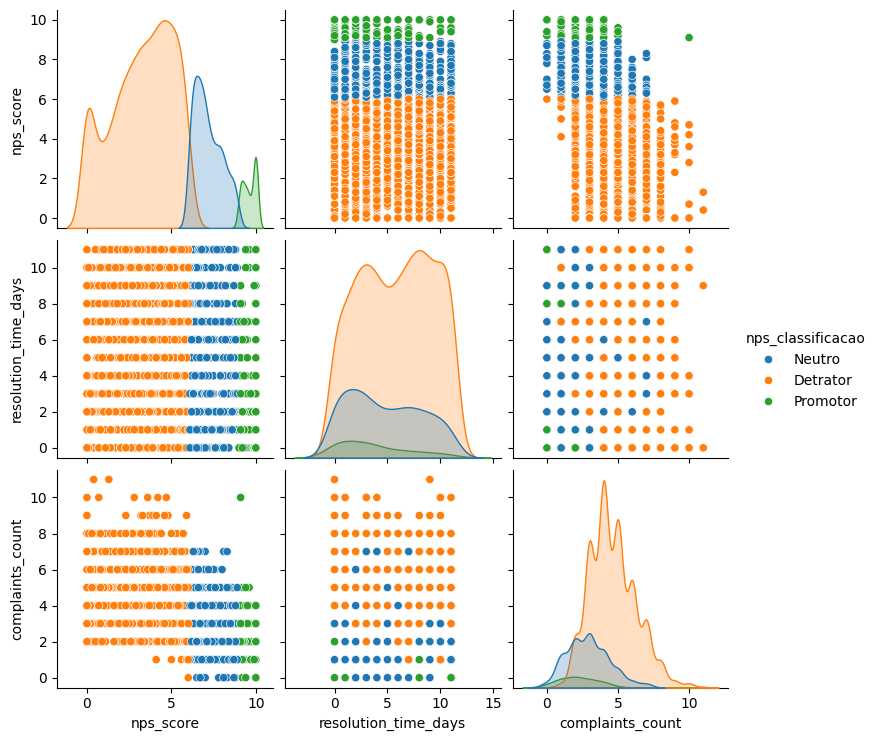

In [ ]:
sns.pairplot(ds_nps_7, hue = 'nps_classificacao')

In [ ]:
Conclusões da análise gráfica:

* Há correlação negativa entre reclamações e nps (quanto maior o score, menos reclamações)
* Não há relação entre nps e tempo de resolução de problemas.

**Análise por NPS e região**


In [ ]:
ds_nps_8 = nps.groupby("customer_region")["nps_score"].mean().sort_values(ascending=False)
ds_nps_8.head(6)

,nps_score
customer_region,
Sul,4.490979
Nordeste,4.421649
Norte,4.382609
Sudeste,4.373846
Centro-Oeste,4.209829


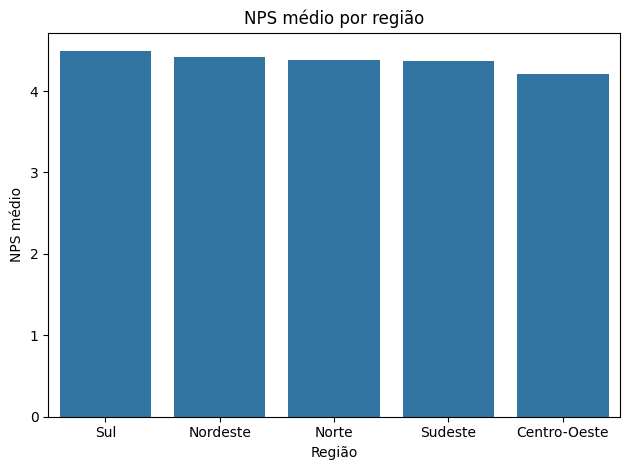

In [ ]:
plt.figure()
sns.barplot(x=ds_nps_8.index, y=ds_nps_8.values)
plt.title("NPS médio por região")
plt.xlabel("Região")
plt.ylabel("NPS médio")
plt.tight_layout()
plt.show()

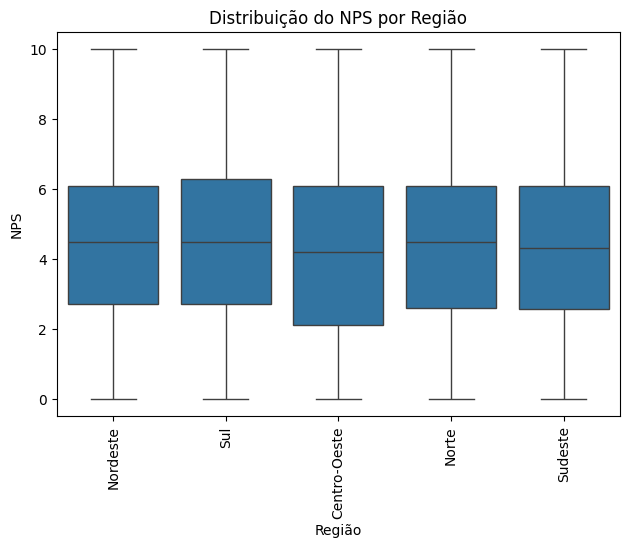

In [ ]:
#Boxsplot
plt.figure()
sns.boxplot(data=nps, x="customer_region", y="nps_score")
plt.title("Distribuição do NPS por Região")
plt.xlabel("Região")
plt.ylabel("NPS")
plt.tight_layout()
plt.xticks(rotation = 90);
plt.show()

Conclusão de análise gráfica:
* Região Sul tende a ter uma média mais alta de NPS.
* Não existem outliers.

**Análise por NPS e informações de pedido**


In [ ]:
ds_nps_9 = nps[['nps_score','discount_value','nps_classificacao','payment_installments','order_value']]

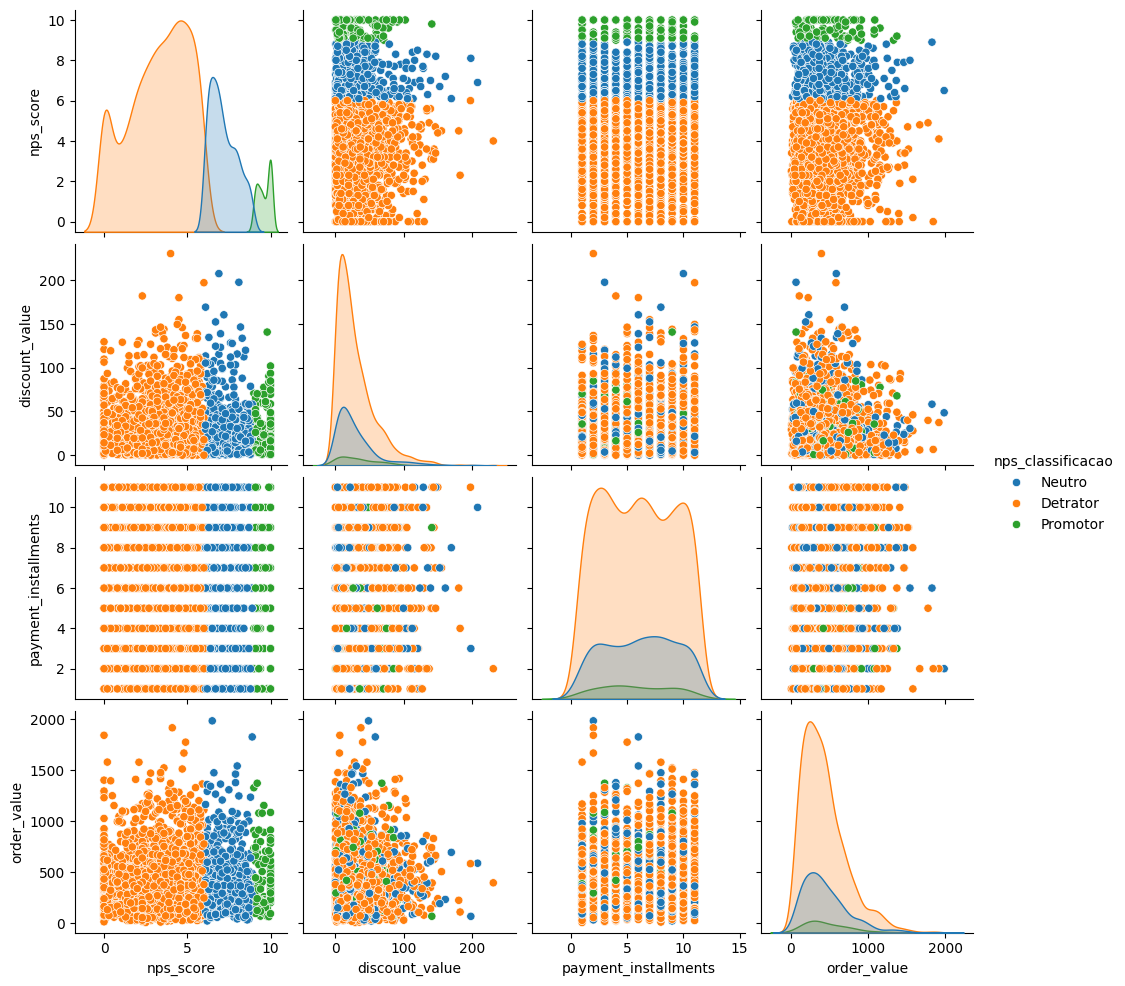

In [ ]:
sns.pairplot(ds_nps_9, hue = 'nps_classificacao')

In [ ]:
Conclusões da análise gráfica:
* Não há relação entre NPS e valor do pedido.
* Não há relação entre desconto e NPS.

**Tentando encontrar correlações por outros tipos de gráficos**


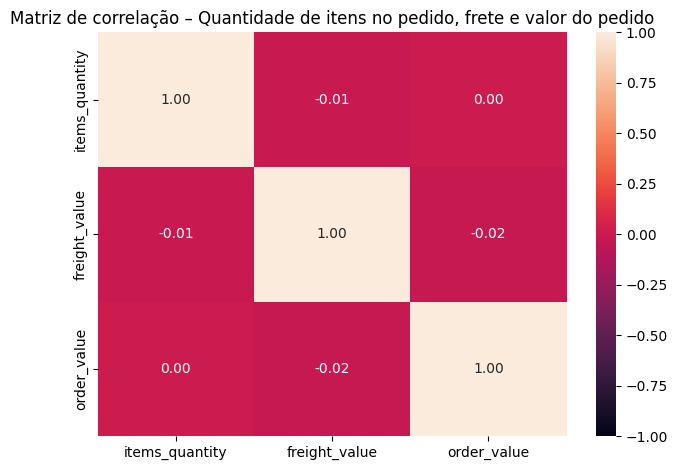

In [ ]:
cols_corr = [c for c in ["items_quantity","freight_value","order_value"] if c in nps.columns]
corr = nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Quantidade de itens no pedido, frete e valor do pedido")
plt.tight_layout()
plt.show()

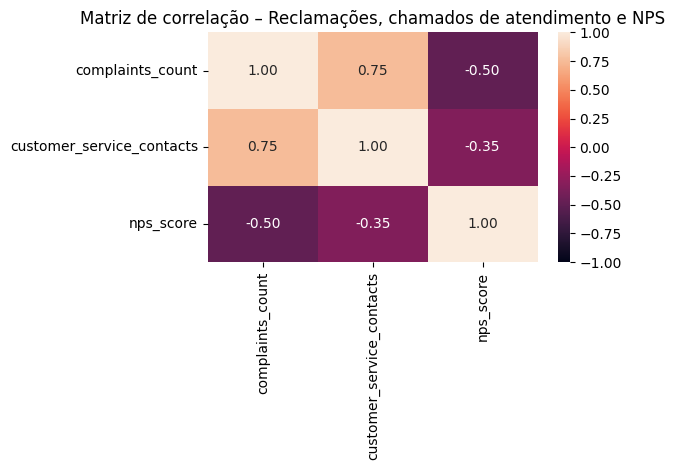

In [ ]:
cols_corr = [c for c in ["complaints_count","customer_service_contacts","nps_score"] if c in nps.columns]
corr = nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Reclamações, chamados de atendimento e NPS")
plt.tight_layout()
plt.show()

Conclusão gráfica:
- Essa matriz reafirma a leitura acima feita no gráfica de dispersão de que há um certa relação linear positiva entre quantidade de reclamações e quantidade de contatos no atendimento através da correlação de 0.75 (diretamente proporcional).

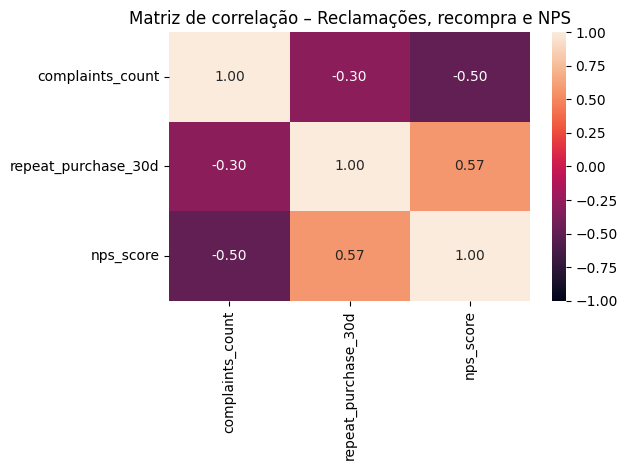

In [ ]:
cols_corr = [c for c in ["complaints_count","repeat_purchase_30d","nps_score"] if c in nps.columns]
corr = nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Reclamações, recompra e NPS")
plt.tight_layout()
plt.show()

Conclusão gráfica:
- Mesma validação de que há uma correlação entre NPS e chance de voltar a comprar em 30 dias (diretamente proporcional). Assim como a correlação negativa entre NPS e quantidade de reclamações.

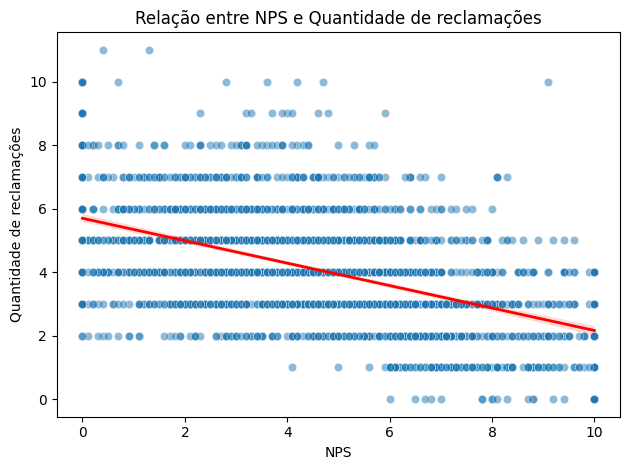

In [ ]:
sns.scatterplot(data=nps, x="nps_score", y="complaints_count", alpha=0.5)

# Linha de tendência com regplot
sns.regplot(
         data=nps,
        x="nps_score",
        y="complaints_count",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Relação entre NPS e Quantidade de reclamações")
plt.xlabel("NPS")
plt.ylabel("Quantidade de reclamações")
plt.tight_layout()
plt.show()

Conclusão:
- Reafirma a mesma conclusão dos gráficos acima, quanto maior o NPS, menor o número de reclamações.

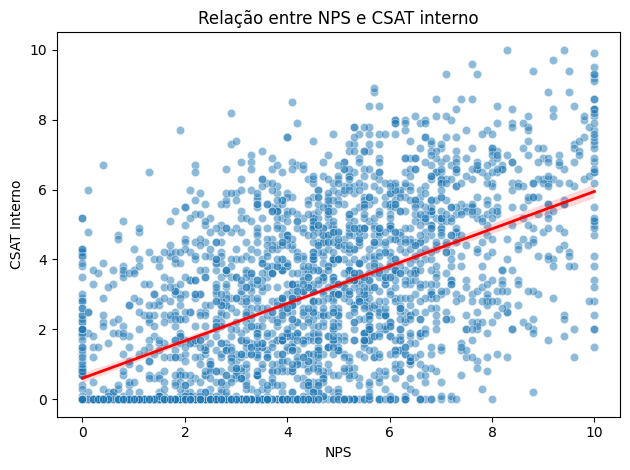

In [ ]:
sns.scatterplot(data=nps, x="nps_score", y="csat_internal_score", alpha=0.5)

# Linha de tendência com regplot
sns.regplot(
         data=nps,
        x="nps_score",
        y="csat_internal_score",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Relação entre NPS e CSAT interno")
plt.xlabel("NPS")
plt.ylabel("CSAT Interno")
plt.tight_layout()
plt.show()

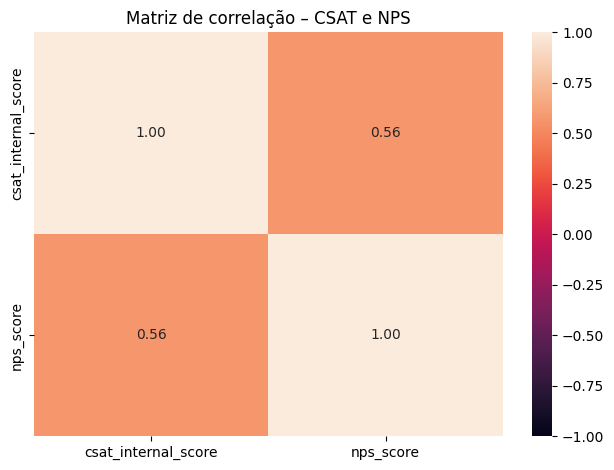

In [ ]:
cols_corr = [c for c in ["csat_internal_score","nps_score"] if c in nps.columns]
corr = nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – CSAT e NPS")
plt.tight_layout()
plt.show()

Conclusão:
* Há alguma correlação diretamente proporcional entre NPS e CSAT porém não é tão expressiva (0.56).

# 1.4. Conclusão da Análise Exploratória dos Dados

A partir das explorações gráficas acima podemos chegar as seguintes conclusões:
* Os fatores mais críticos para a satisfação são: quantidade de reclamações,quantidade de contatos no atendimento, dias de atraso na entrega.
* Quanto maior a quantidade de contatos no atendimento, maior a quantidade de reclamações.
* Detratores não estão concentrados somente em grandes índices de tempo de atraso de entrega, estão presentes em qualquer índice de atraso. Porém, certamente a grande maioria dos promotores (75% percentil) está concetrada em índices mais baixos de atraso.
* Existe um ponto de ruptura na experiência do cliente: Não existem promotores (apenas um outlier) quando há mais de 5 reclamações no atendimento.
* Com relação ao CSAT, quanto mais alto, menor a quantidade de contatos no atendimento. Porém não parece ser um indicador confiável para tentar prever a satisfação do consumidor antes de aplicar o NPS porque a correlação não é tão expressiva. Uma hipótese é que o CSAT seja um indicador de baixa qualidade para medir satisfação porque pode ser um indicador passível de "target drift".

* Há relação direta entre um alto NPS e o índice de recompra dentro de 30 dias.


* Não há relação entre NPS e idade, valor do pedido, tempo de entrega geral e tempo de resolução de problemas. A região do Brasil também não interfere signifivamente na satisfação. Também não há relação entre aumento de satisfação com aumento de descontos.

*OBS.: Como foi citado acima, a base de dados .csv pode tornar a avaliação suscetível a armadilhas de: definições mutantes ou target drift visto que os pedidos não possuem data e não foi possível avaliar se a amostragem de fato representa a população.*